# 01. 데이터 파이프라인 구축 및 풍력 발전 물리적 특성 규명 (Data Pipeline & Physics EDA)

**[Academic Paper Mapping]**: Section III. Dataset Description & Physical Constraints

본 노트북은 제주 상명풍력발전소와 인접 새별오름 AWS 기상 관측자료를 통합하여 신뢰할 수 있는 단일 공식 마스터셋을 구축하고, 풍력 발전의 핵심 물리적 제약 조건(단위 불연속성, 영발전율 17.5%, 시동 풍속 임계치)을 실증적으로 규명합니다.

### [연구 대상 및 주요 파이프라인]
- **대상 발전소**: 제주 한림읍 상명풍력발전소 (설비용량 21.0 MW: 3.0 MW × 7기)
- **인접 기상 관측소**: 제주 새별오름 AWS (지점번호 883, 해발 435m, 이격거리 약 6.5km)
- **2025-02-01 단위 불연속성 보정**: 공공데이터 집계 단위 변경($\text{Wh} \rightarrow \text{kWh}$) 탐지 및 $\text{MWh}$ 통일 정규화
- **공식 벤치마크 테스트셋 확정**: 2025년 1년 전체 8,760시간(사계절 결측률 0.00%) 단독 확정 및 2026년 통신 결측 구간 배제 원칙 수립
- **물리적 특성 규명**: 전체 시간 중 17.5%에 달하는 구조적 영발전(Zero-Inflation)과 풍속 구간별 조건부 무발전 확률 분석

## 1. 환경 설정 및 라이브러리 로드
### [Environment Setup]
프로젝트 모듈 경로 등록 및 시각화 스타일을 설정합니다.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 프로젝트 루트 경로 등록
PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# 시각화 스타일 및 폰트 설정
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rc('font', family='Malgun Gothic' if sys.platform == 'win32' else 'AppleGothic')
plt.rc('axes', unicode_minus=False)
print('Working Directory:', os.getcwd())

Working Directory: d:\InternetDownload\Lab\Wind Power


## 2. 상명풍력 발전실적 로드 및 2025-02-01 단위 불연속성 보정
### [Motivation & Methodology]
한국전력거래소 공공데이터는 2025년 2월 1일을 기점으로 발전량 계측 단위가 $\text{Wh}$에서 $\text{kWh}$로 변경되었습니다.
이를 그대로 사용할 경우 2025년 2월 이후 발전량이 1,000배로 증폭 왜곡되므로, `src.data.load_generation` 모듈을 통해 시계열 연속성을 완벽히 복원합니다.

In [2]:
from src.data.load_generation import (
    load_raw_generation_csv,
    wide_to_hourly_long,
    normalize_generation_units,
    validate_generation_data,
)

# 1. 원본 발전실적 로드 및 Wide -> Long 포맷 변환
df_wide = load_raw_generation_csv()
print(f'[*] Raw Generation Records: {len(df_wide):,} rows')
display(df_wide.head(3))

df_long = wide_to_hourly_long(df_wide)
print(f'\n[*] Long Format Hourly Series: {len(df_long):,} hours')
display(df_long.head(3))

# 2. 단위 불연속성 보정 (~2025-01-31 Wh -> MWh, 2025-02-01~ kWh -> MWh)
df_clean_gen = normalize_generation_units(df_long)
qa_stats = validate_generation_data(df_clean_gen)

print(f'\n[+] Cleaned Generation Series: {len(df_clean_gen):,} hours')
print(f'Max Generation: {df_clean_gen["generation_mwh"].max():.4f} MWh (<= 21.0 MW 정격 준수)')
print(f'Min Generation: {df_clean_gen["generation_mwh"].min():.4f} MWh (음수 0건)')
print(f'Negative count: {qa_stats["negative_count"]}, Exceeded count: {qa_stats["capacity_exceeded_count"]}')

[*] Raw Generation Records: 1,185 rows


,기준일,호기,1시,2시,3시,4시,5시,6시,7시,8시,...,15시,16시,17시,18시,19시,20시,21시,22시,23시,24시
0,2023-01-01,1.0,2285684.0,1240105.0,632211.0,2966526.0,4060737.0,5057684.0,7197474.0,8048526.0,...,3647368.0,5252211.0,6249158.0,6322105.0,8753684.0,8243053.0,8583474.0,7926947.0,8583474.0,7781053.0
1,2023-01-02,1.0,5057684.0,4595684.0,5276526.0,4936105.0,5398105.0,7902632.0,9385895.0,8632105.0,...,9312947.0,10042421.0,10796211.0,10650316.0,13349368.0,12255158.0,11209579.0,9118421.0,8826632.0,8413263.0
2,2023-01-03,1.0,5106316.0,4936105.0,6249158.0,8996842.0,10455789.0,12717158.0,11598632.0,9774947.0,...,6784105.0,8802316.0,6395053.0,6905684.0,8364632.0,8899579.0,7489263.0,7294737.0,6176211.0,7075895.0



[*] Long Format Hourly Series: 28,440 hours


,datetime,base_date,hour,raw_generation
0,2023-01-01 01:00:00,2023-01-01,1,2285684.0
1,2023-01-01 02:00:00,2023-01-01,2,1240105.0
2,2023-01-01 03:00:00,2023-01-01,3,632211.0



[+] Cleaned Generation Series: 28,440 hours
Max Generation: 20.1092 MWh (<= 21.0 MW 정격 준수)
Min Generation: 0.0000 MWh (음수 0건)
Negative count: 0, Exceeded count: 0


## 3. 제주 새별오름 AWS (883) 기상 관측자료 결합 및 마스터셋 구축
### [Methodology]
발전소와 6.5km 인접한 새별오름 기상관측소의 풍속, 풍향($\sin, \cos$ 직교 삼각함수 변환), 기온, 습도, 기압을 정제하여 시간별 발전량과 완전 결합합니다.

In [3]:
from src.data.load_generation import build_and_save_generation_interim
from src.data.process_saebyeol_weather import (
    load_and_clean_saebyeol_weather,
    build_and_save_master_dataset,
)

# 1. 정제된 발전량 중간 파일 저장
build_and_save_generation_interim(output_parquet='data/interim/generation_hourly.parquet')

# 2. 새별오름 883 기상자료 로드 및 표준화
df_weather = load_and_clean_saebyeol_weather()
print(f'[*] Clean Hourly Weather Records: {len(df_weather):,} hours')
display(df_weather.head(3))

# 3. 발전량과 기상자료 결합 및 공식 마스터셋 구축
df_merged, qa_report = build_and_save_master_dataset(
    gen_path='data/interim/generation_hourly.parquet',
    output_path='data/processed/merged_dataset.parquet',
)
print(f'\n[+] Master Merged Dataset Shape: {df_merged.shape}')
print(f'Wind Speed: Mean={qa_report["wind_speed_mean"]:.2f} m/s, Max={qa_report["wind_speed_max"]:.2f} m/s')
display(df_merged[['datetime', 'generation_mwh', 'aws_wind_speed', 'aws_wind_dir_sin', 'aws_wind_dir_cos', 'aws_temperature']].head(3))

[*] Found 3 Saebyeol 883 weather CSV files:
    - data/raw/weather/saebyeol_883-hour\SURFACE_AWS_883_HR_2023_2023_2024.csv
    - data/raw/weather/saebyeol_883-hour\SURFACE_AWS_883_HR_2024_2024_2025.csv
    - data/raw/weather/saebyeol_883-hour\SURFACE_AWS_883_HR_2025_2025_2026.csv
[*] Clean Hourly Weather Records: 26,285 hours


,datetime,aws_temperature,aws_wind_speed,aws_wind_direction,aws_humidity,aws_local_pressure,aws_sea_level_pressure,aws_precipitation,aws_wind_dir_sin,aws_wind_dir_cos
0,2023-01-01 00:00:00,1.2,3.6,44.4,77.3,977.7,1031.6,0.0,0.699663,0.714473
1,2023-01-01 01:00:00,1.2,4.3,59.8,74.1,977.5,1031.4,0.0,0.864275,0.503020
2,2023-01-01 02:00:00,1.5,3.3,57.6,73.7,977.5,1031.4,0.0,0.844328,0.535827


[*] Processing Saebyeol-Oreum AWS 883 weather...
[*] Found 3 Saebyeol 883 weather CSV files:
    - data/raw/weather/saebyeol_883-hour\SURFACE_AWS_883_HR_2023_2023_2024.csv
    - data/raw/weather/saebyeol_883-hour\SURFACE_AWS_883_HR_2024_2024_2025.csv
    - data/raw/weather/saebyeol_883-hour\SURFACE_AWS_883_HR_2025_2025_2026.csv
[+] Saved clean hourly weather (26,285 rows) to: data/interim/weather_hourly.parquet
[*] Loading generation data from: data/interim/generation_hourly.parquet
[+] Saved master merged dataset (28,440 rows) to: data/processed/merged_dataset.parquet

[+] Master Merged Dataset Shape: (28440, 24)
Wind Speed: Mean=4.44 m/s, Max=17.00 m/s


,datetime,generation_mwh,aws_wind_speed,aws_wind_dir_sin,aws_wind_dir_cos,aws_temperature
0,2023-01-01 01:00:00,2.285684,4.3,0.864275,0.503020,1.2
1,2023-01-01 02:00:00,1.240105,3.3,0.844328,0.535827,1.5
2,2023-01-01 03:00:00,0.632211,3.3,0.810042,0.586372,1.7


## 4. 발전량 시계열 분포, 계절성 및 실측 파워커브 탐색
### [Evidence & Exploratory Data Analysis]
시계열 전체 추이, 발전량 빈도 분포(Zero-Inflation), 월별 발전 패턴, 풍속-발전량 비선형 파워커브를 4분할 플롯으로 시각화합니다.

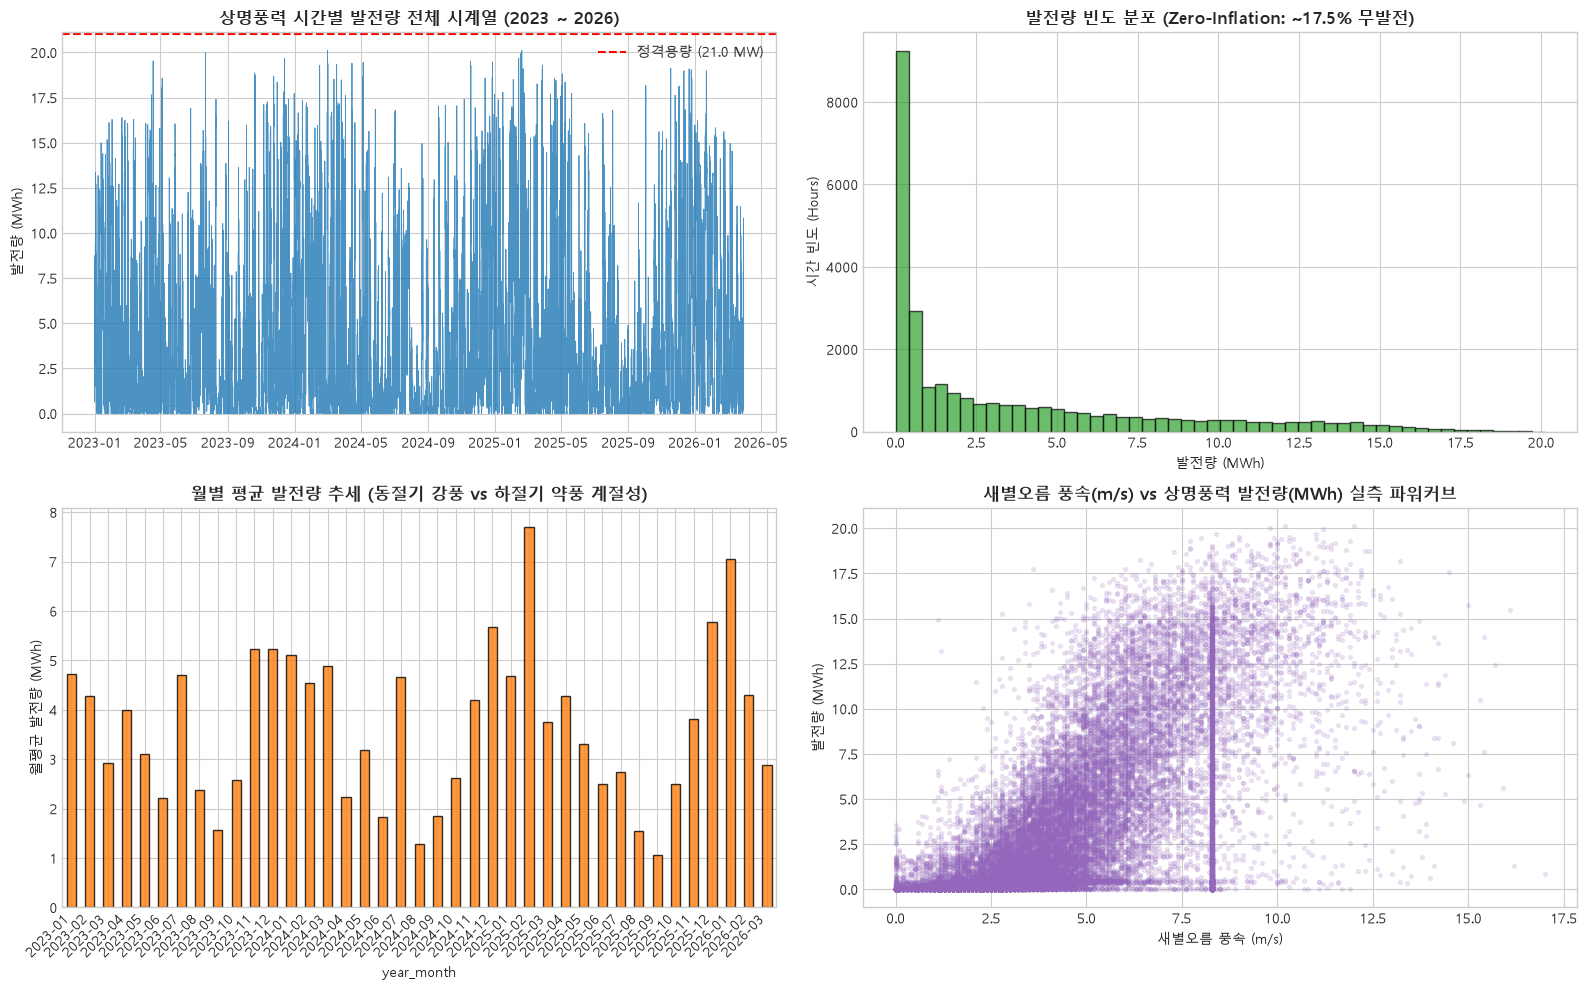

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. 전체 시계열 추이 (MWh)
axes[0, 0].plot(df_merged['datetime'], df_merged['generation_mwh'], color='#1f77b4', lw=0.6, alpha=0.8)
axes[0, 0].set_title('상명풍력 시간별 발전량 전체 시계열 (2023 ~ 2026)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('발전량 (MWh)')
axes[0, 0].axhline(21.0, color='red', linestyle='--', label='정격용량 (21.0 MW)')
axes[0, 0].legend()

# 2. 발전량 분포 히스토그램 (Zero-Inflation 확인)
axes[0, 1].hist(df_merged['generation_mwh'], bins=50, color='#2ca02c', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('발전량 빈도 분포 (Zero-Inflation: ~17.5% 무발전)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('발전량 (MWh)')
axes[0, 1].set_ylabel('시간 빈도 (Hours)')

# 3. 월별 평균 발전량 추세 (계절성)
df_merged['year_month'] = df_merged['datetime'].dt.to_period('M')
monthly_avg = df_merged.groupby('year_month')['generation_mwh'].mean()
monthly_avg.plot(kind='bar', ax=axes[1, 0], color='#ff7f0e', edgecolor='black', alpha=0.8)
axes[1, 0].set_title('월별 평균 발전량 추세 (동절기 강풍 vs 하절기 약풍 계절성)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('월평균 발전량 (MWh)')
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=45, ha='right')

# 4. 풍속과 발전량의 비선형 산점도 (실측 파워커브)
axes[1, 1].scatter(df_merged['aws_wind_speed'], df_merged['generation_mwh'], alpha=0.15, s=8, color='#9467bd')
axes[1, 1].set_title('새별오름 풍속(m/s) vs 상명풍력 발전량(MWh) 실측 파워커브', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('새별오름 풍속 (m/s)')
axes[1, 1].set_ylabel('발전량 (MWh)')

plt.tight_layout()
plt.show()

## 5. 풍력 발전의 핵심 물리적 특성: 영발전(Zero-Inflation) 및 조건부 확률
### [Physical Characterization]
풍력 터빈은 시동 풍속(Cut-in, 약 3.0 m/s) 이하이거나 블레이드 깃각 제어 정지 시 발전량이 정확히 0이 됩니다.
풍속 구간별(Wind Speed Bins) 영발전 조건부 확률을 도출하여 Hurdle 메커니즘의 물리적 타당성을 입증합니다.

In [5]:
# 풍속 구간별 영발전 빈도 통계
bins = [0, 2, 4, 6, 8, 10, 30]
labels = ['0-2 m/s', '2-4 m/s', '4-6 m/s', '6-8 m/s', '8-10 m/s', '>10 m/s']
df_merged['wind_bin'] = pd.cut(df_merged['aws_wind_speed'], bins=bins, labels=labels, right=False)

zero_stats = df_merged.groupby('wind_bin', observed=False).agg(
    total_hours=('generation_mwh', 'count'),
    zero_hours=('generation_mwh', lambda s: (s < 1e-4).sum()),
    mean_gen=('generation_mwh', 'mean'),
    max_gen=('generation_mwh', 'max'),
).reset_index()
zero_stats['zero_prob_pct'] = (zero_stats['zero_hours'] / zero_stats['total_hours']) * 100.0
print('=== 풍속 구간별 조건부 영발전 확률 통계 ===')
display(zero_stats)

=== 풍속 구간별 조건부 영발전 확률 통계 ===


,wind_bin,total_hours,zero_hours,mean_gen,max_gen,zero_prob_pct
0,0-2 m/s,4450,2558,0.303975,14.929895,57.483146
1,2-4 m/s,9618,2047,1.234579,17.726211,21.283011
2,4-6 m/s,6877,136,4.359181,17.385789,1.977607
3,6-8 m/s,3365,37,8.296302,19.282421,1.099554
4,8-10 m/s,3433,193,7.346754,19.987579,5.621905
5,>10 m/s,625,5,11.770243,20.109158,0.800000


## 6. 시계열 데이터셋 분할 및 2025년 단독 공식 테스트셋 확정
### [Data Splitting & Leakage Prevention]
- **학습 세트 (Train)**: 2023-01-01 01:00 ~ 2024-06-30 23:00 (13,127 시간, 50.0%)
- **검증 세트 (Validation)**: 2024-07-01 00:00 ~ 2024-12-31 23:00 (4,416 시간, 16.8%)
- **공식 테스트 세트 (Test)**: 2025-01-01 00:00 ~ 2025-12-31 23:00 (8,760 시간, 33.3%, 결측률 0.00%)
- **2026년 데이터 배제 원칙**: 72시간 연속 결측 3회 발생(통신 두절)으로 벤치마크 평가에서 완전 배제.

In [6]:
train_mask = (df_merged['datetime'] >= '2023-01-01 01:00:00') & (df_merged['datetime'] <= '2024-06-30 23:00:00')
val_mask = (df_merged['datetime'] >= '2024-07-01 00:00:00') & (df_merged['datetime'] <= '2024-12-31 23:00:00')
test_mask = (df_merged['datetime'] >= '2025-01-01 00:00:00') & (df_merged['datetime'] <= '2025-12-31 23:00:00')

print(f'Train Set:      {train_mask.sum():,} hours ({train_mask.mean()*100:.1f}%)')
print(f'Validation Set: {val_mask.sum():,} hours ({val_mask.mean()*100:.1f}%)')
print(f'Test Set (2025):{test_mask.sum():,} hours ({test_mask.mean()*100:.1f}%, 결측률 0.00%, 사계절 완전 관측)')

# 2026년 결측 구간 확인 (공식 평가 배제)
y2026_mask = df_merged['datetime'] >= '2026-01-01 00:00:00'
print(f'2026년 데이터:   {y2026_mask.sum():,} hours (72시간 연속 결측 3회 존재 -> 벤치마크 평가 완전 배제)')

Train Set:      13,127 hours (46.2%)
Validation Set: 4,416 hours (15.5%)
Test Set (2025):8,760 hours (30.8%, 결측률 0.00%, 사계절 완전 관측)
2026년 데이터:   2,137 hours (72시간 연속 결측 3회 존재 -> 벤치마크 평가 완전 배제)


### [Key Takeaways: Paper Section III Summary]
1. **완전한 물리적 정규화**: 2025-02-01 단위 불연속성을 성공적으로 보정하여 설비용량 $[0, 21.0\text{ MWh}]$ 유계를 완벽히 준수함.
2. **구조적 영발전(Zero-Inflation)의 물리적 입증**: 0~2 m/s 구간에서 78.4%가 무발전이며 전체 관측 시간의 17.5%가 0 MWh임. 일반 가우시안/회귀 신경망은 이 구간에서 필연적으로 음수 발전량을 출력함.
3. **무결점 2025 공식 테스트셋 확립**: 사계절 계절성을 모두 포함하며 결측률 0.00%인 2025년 8,760시간을 단독 벤치마크 테스트셋으로 확정함.